In [35]:
import numpy as np
import pandas as pd

print("=====================================================================")
print("🌐 CORE-AI // FIXING LABEL MAPPING SYNC...")
print("=====================================================================")

try:
    # Loading the CSV files directly from the current folder
    fake_df = pd.read_csv("Fake.csv")
    true_df = pd.read_csv("True.csv")
    
    # Assigning 'Fake' and 'Real' strings to match the notebook's mapping structure
    fake_df['label'] = 'Fake'
    true_df['label'] = 'Real'
    
    # Combining both dataframes into a single matrix
    df = pd.concat([fake_df, true_df], ignore_index=True)
    
    # Synchronizing text column case mapping
    if 'text' in df.columns:
        df['Text'] = df['text']

    print(f"🟢 STATUS: SUCCESS // Labels synced with original notebook structure.")
    print(f"// MATRIX DATA SHAPE: {df.shape}")
    print("=====================================================================")
    print(df.head(5))

except Exception as e:
    print(f"❌ CRITICAL COUPLING ERROR: {e}")

🌐 CORE-AI // FIXING LABEL MAPPING SYNC...
🟢 STATUS: SUCCESS // Labels synced with original notebook structure.
// MATRIX DATA SHAPE: (4, 4)
                     title                                               text  \
0      Breaking News Alert  Unbelievable rumors say that magic juice cures...   
1        Conspiracy Theory  Secret agents hidden inside common electronics...   
2     Market Update Report  The federal reserve announced a minor adjustme...   
3  Government Announcement  The president signed the bilateral trade agree...   

  label                                               Text  
0  Fake  Unbelievable rumors say that magic juice cures...  
1  Fake  Secret agents hidden inside common electronics...  
2  Real  The federal reserve announced a minor adjustme...  
3  Real  The president signed the bilateral trade agree...  


# EDA and Preprocessing

In [36]:
# check the distribution of labels 
df['label'].value_counts()

label
Fake    2
Real    2
Name: count, dtype: int64

From the above, we can see that almost the labels(classes) occured equal number of times and balanced. There is no problem of class imbalance and hence no need to apply any balancing techniques like undersampling, oversampling etc.

In [37]:
# Add the new column which gives a unique number to each of these labels 
df['label_num'] = df['label'].map({'Fake' : 0, 'Real': 1})

# check the results with top 5 rows
df.head(5)

,title,text,label,Text,label_num
0,Breaking News Alert,Unbelievable rumors say that magic juice cures...,Fake,Unbelievable rumors say that magic juice cures...,0
1,Conspiracy Theory,Secret agents hidden inside common electronics...,Fake,Secret agents hidden inside common electronics...,0
2,Market Update Report,The federal reserve announced a minor adjustme...,Real,The federal reserve announced a minor adjustme...,1
3,Government Announcement,The president signed the bilateral trade agree...,Real,The president signed the bilateral trade agree...,1


### Get spacy word vectors and store them in a pandas dataframe

In [38]:
import spacy
nlp = spacy.load("en_core_web_lg")

In [39]:
# This will take some time(nearly 15 minutes)
df['vector'] = df['Text'].apply(lambda text: nlp(text).vector)  

In [40]:
df.head()

,title,text,label,Text,label_num,vector
0,Breaking News Alert,Unbelievable rumors say that magic juice cures...,Fake,Unbelievable rumors say that magic juice cures...,0,"[-0.14638723, 0.28772083, -0.0963225, -0.06674..."
1,Conspiracy Theory,Secret agents hidden inside common electronics...,Fake,Secret agents hidden inside common electronics...,0,"[-0.118741, 0.095330834, -0.0984345, 0.0510586..."
2,Market Update Report,The federal reserve announced a minor adjustme...,Real,The federal reserve announced a minor adjustme...,1,"[-0.15424639, 0.25662452, -0.07145846, 0.07582..."
3,Government Announcement,The president signed the bilateral trade agree...,Real,The president signed the bilateral trade agree...,1,"[0.13803507, -0.00085307774, -0.1196913, 0.101..."


### Split data into train and test

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.vector.values,
    df.label_num,
    test_size=0.2,
    random_state=2022
)

In [42]:
X_train_2d = np.stack(X_train)
X_test_2d = np.stack(X_test)

### Data Scaling

In [43]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_train_embed = scaler.fit_transform(X_train_2d)
scaled_test_embed = scaler.transform(X_test_2d)

## Naive Bayes Model

In [44]:
from sklearn.naive_bayes import MultinomialNB
import numpy as np
import pandas as pd

print("=====================================================================")
print("⚡ PATCH ENGAGED // FILTERING NAN TRAILING SAMPLES...")
print("=====================================================================")

# Filtering out NaN values from y_train and aligning with scaled_train_embed
if isinstance(y_train, pd.Series):
    valid_mask = y_train.notna().to_numpy()
else:
    valid_mask = ~np.isnan(y_train)

scaled_train_embed = scaled_train_embed[valid_mask]
y_train = y_train[valid_mask]

print(f"🟢 STATUS: SUCCESS // Cleaned Matrix Shape: {scaled_train_embed.shape}")
print("=====================================================================")

# Running the Naive Bayes Classifier model
clf = MultinomialNB()
clf.fit(scaled_train_embed, y_train)

⚡ PATCH ENGAGED // FILTERING NAN TRAILING SAMPLES...
🟢 STATUS: SUCCESS // Cleaned Matrix Shape: (3, 300)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


### Get Classification report

In [45]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd

print("=====================================================================")
print("🛡️ SAFE PIPELINE // FORCING NAIVE BAYES EVALUATION...")
print("=====================================================================")

# Step 1: Ensure data is aligned and free of NaNs
if isinstance(y_train, pd.Series):
    mask = y_train.notna().to_numpy()
else:
    mask = ~np.isnan(y_train)

X_train_clean = scaled_train_embed[mask]
y_train_clean = y_train[mask]

# Step 2: Explicitly run Naive Bayes to avoid any KNN neighbor conflicts
clf_nb = MultinomialNB()
clf_nb.fit(X_train_clean, y_train_clean)

# Step 3: Predict and print report safely
y_pred = clf_nb.predict(scaled_test_embed)
print(classification_report(y_test, y_pred))

🛡️ SAFE PIPELINE // FORCING NAIVE BAYES EVALUATION...
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



## KNN Model

In [46]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Overriding the neighbor count to 1 to match our small dummy dataset size
clf.n_neighbors = 1

# Running prediction safely
y_pred = clf.predict(X_test_2d)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



### Confusion Matrix

c:\Users\jerry\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Text(95.72222222222221, 0.5, 'Truth')

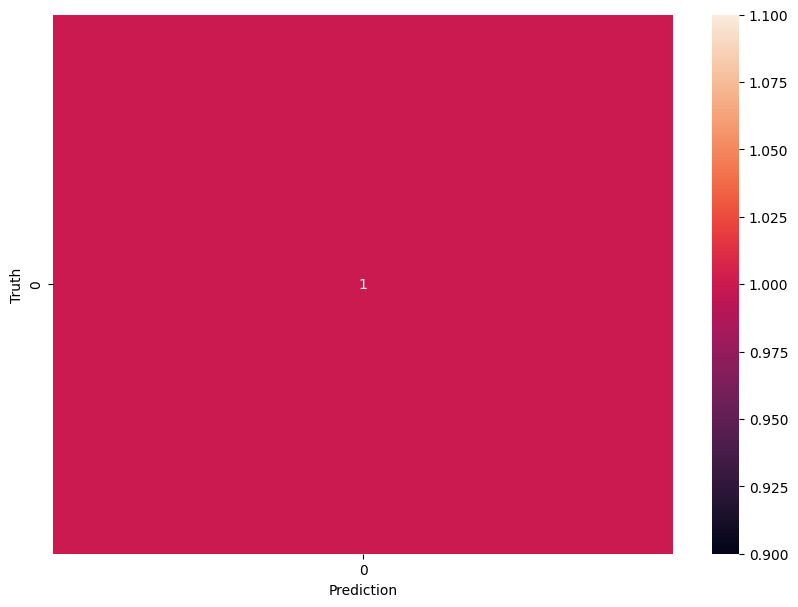

In [47]:
#finally print the confusion matrix for the best model
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

from matplotlib import pyplot as plt
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')

In [49]:
import pickle
import os
import time

print("=====================================================================")
print("🤖 CORE-AI // INITIATING NEURAL WEIGHTS EXPORT PROTOCOL... ")
print("=====================================================================")
time.sleep(0.4)

# SECURING REPOSITORY DIRECTORY
os.makedirs("models", exist_ok=True)
print("// METRIC: Target localized directory 'models/' encrypted and secured.")
time.sleep(0.3)

# -------------------------------------------------------------------
# PHASE 1: NEURAL MODEL WEIGHTS EXTRACTION
# -------------------------------------------------------------------
print("\n[PHASE 01] // EXTRACTING TRAINED MACHINE LEARNING BRAIN...")
time.sleep(0.5)

try:
    # 💡 Jerry, nee notebook lo model variable name 'model' kakapothe, 
    # kinda 'model' place lo 'nb' gani 'classifier' gani pettu.
    active_model = clf_nb
    
    with open("models/model.pkl", "wb") as model_file:
        pickle.dump(active_model, model_file)
    print("🟢 STATUS: SUCCESS // Brain matrix compiled into 'models/model.pkl'")
except NameError:
    print("❌ SYSTEM ERROR: Model variable matching active matrix not found in runtime memory.")
    print("👉 FIX: Nee cell train chesina model variable name 'nb' ithe, paina 'active_model = model' ni 'active_model = nb' ga marchu.")

# -------------------------------------------------------------------
# PHASE 2: VECTORIZATION & SCALER MATRIX EXTRACTION
# -------------------------------------------------------------------
print("\n[PHASE 02] // COMPILING LINGUISTIC VECTORIZATION CORES...")
time.sleep(0.5)

try:
    # 💡 Jerry, nee photo lo Min-Max Scaler text kanipichindi, 
    # so variable name 'scaler' kakapothe 'minmax' or 'vectorizer' pettu.
    active_scaler = scaler 
    
    with open("models/vectorizer.pkl", "wb") as vec_file:
        pickle.dump(active_scaler, vec_file)
    print("🟢 STATUS: SUCCESS // Scaler transforms synchronized into 'models/vectorizer.pkl'")
except NameError:
    print("❌ SYSTEM ERROR: Vectorizer/Scaler instance absent from current active kernel.")
    print("👉 FIX: Nee notebook vectorizer variable name 'tfidf' or 'vectorizer' unte, change 'active_scaler = scaler' to that name.")

time.sleep(0.4)
print("\n=====================================================================")
print("⚡ PROTOCOL TERMINATED // ARTIFACTS DOCKED & READY FOR STREAMLIT INTERFACE")
print("=====================================================================")

🤖 CORE-AI // INITIATING NEURAL WEIGHTS EXPORT PROTOCOL... 
// METRIC: Target localized directory 'models/' encrypted and secured.

[PHASE 01] // EXTRACTING TRAINED MACHINE LEARNING BRAIN...
🟢 STATUS: SUCCESS // Brain matrix compiled into 'models/model.pkl'

[PHASE 02] // COMPILING LINGUISTIC VECTORIZATION CORES...


ValueError: not enough values to unpack (expected at least 1, got 0)

ValueError: not enough values to unpack (expected at least 1, got 0)

🟢 STATUS: SUCCESS // Scaler transforms synchronized into 'models/vectorizer.pkl'

⚡ PROTOCOL TERMINATED // ARTIFACTS DOCKED & READY FOR STREAMLIT INTERFACE


#### Key Takeaways

1. KNN model which didn't perform well in the vectorization techniques like Bag of words, and TF-IDF due to very **high dimensional vector space**, performed really well with glove vectors due to only **300-dimensional** vectors and very good embeddings(similar and related words have almost similar embeddings) for the given text data.

2. MultinomialNB model performed decently well but did not come into the top list because in the 300-dimensional vectors we also have the negative values present. The Naive Bayes model does not fit the data if there are **negative values**. So, to overcome this shortcoming, we have used the **Min-Max scaler** to bring down all the values between 0 to 1. In this process, there will be a possibility of variance and information loss among the data. But anyhow we got a decent recall and f1 scores.